In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys
import pybamm
import importlib

sys.path.append('..')
import plot_settings
plot_settings.apply()


import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver3
importlib.reload(exp_pybamm_ver3)


from IPython.display import display, Math

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pysr import PySRRegressor, TemplateExpressionSpec
# import mean
from pysr import jl
jl.seval("using Statistics")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


### Procedure

1. Find peaks of $\Delta I$ at $t_0$
2. Extract $c(t0+\Delta t)$ 
3. Use $I,t$ as inputs and compare to $c$


In [74]:
dI = np.load('data_c_dot2.npz')['I_dot']
dc = np.load('data_c_dot2.npz')['cn_dot']

In [75]:
dI = dI.reshape(dI.shape[0],dI.shape[1])
dc = dc.reshape(dc.shape[0],dc.shape[1])

Text(0, 0.5, '$\\dot{I}$')

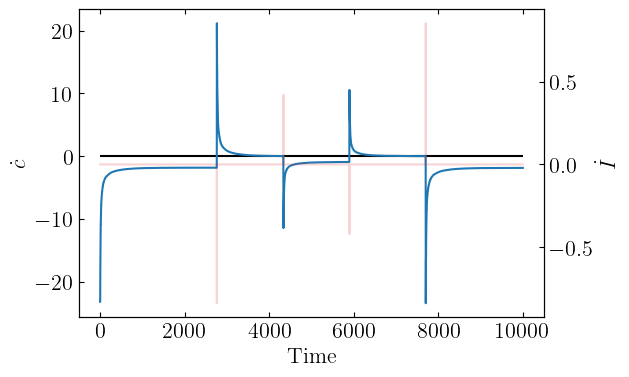

In [185]:
f, ax = plt.subplots(figsize=(6,4))
ax.hlines(0,0,dc.shape[1], label = 'Steady state', color = 'black')
ax.plot(dc[0,:])
axt = ax.twinx()
axt.plot(dI[0,:],color = 'tab:red',alpha = 0.2)
ax.set_xlabel('Time')
ax.set_ylabel(r'$\dot{c}$')
axt.set_ylabel(r'$\dot{I}$')

In [203]:
peak_idx = np.where(dI[:,:]>0.1,1,0)

lag = 1000
dc_decays = []
dI_decay = []
for j,row in enumerate(peak_idx):
    short_idx = np.where(row==1)[0]
    for i in short_idx:
        if i+lag < dc.shape[1]:
            dc_decays = np.append(dc_decays,dc[j,i:i+lag].flatten())
            dI_decay = np.append(dI_decay,dI[j,i] * np.ones(lag))

decays = dc_decays.reshape(int(dc_decays.shape[0]/lag),lag)
dI_decay = dI_decay.reshape(int(dI_decay.shape[0]/lag),lag)

t_decay =np.ones_like(decays) * (np.arange(lag)+1) / 10
inputs = dI_decay

X = np.column_stack([
    dI_decay.flatten(),
    t_decay.flatten()
])

y = decays.flatten()


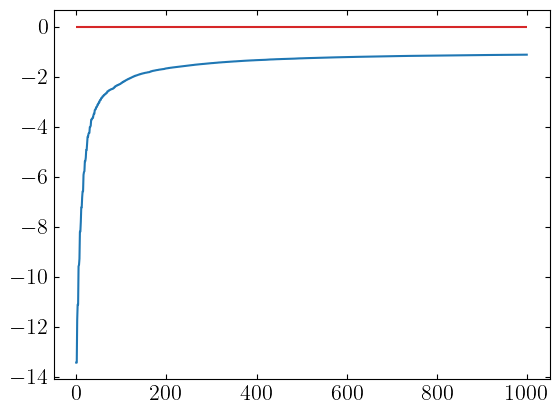

In [204]:
plt.plot(decays[5,:], label = 'Data')
plt.hlines(0,0,lag, label = 'Steady state', color = 'tab:red')

Text(0, 0.5, '$\\dot{I}$')

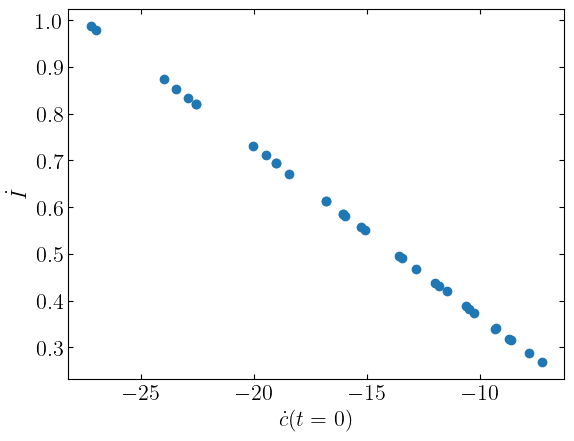

In [205]:
plt.scatter(decays[:,0],dI_decay[:,0], label = 'Data')
plt.xlabel(r'$\dot{c}(t = 0)$')
plt.ylabel(r'$\dot{I}$')

In [151]:
# template = TemplateExpressionSpec(
#     expressions=['f', 'g','h'],
#     variable_names=["x0", "x1"],
#     combine = 'f(x0) * exp(g(x1)) + h(x0,x1)' 
# )

In [206]:
model = PySRRegressor(
    model_selection="score",
    niterations=200,
    binary_operators=[
        "+", "*", '-','/'
    ],
    unary_operators=['exp','sqrt'],
    elementwise_loss="loss(x, y) = mean((x - y).^2)",
    populations=15,
    verbosity=1, 
    batching = True,
    batch_size = 1000,
    maxsize = 20,
)

In [207]:
model.fit(X, y)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 9.420e+03
Progress: 780 / 3000 total iterations (26.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.646e+00  0.000e+00  y = -1.8994
3           2.196e+00  9.308e-02  y = x₀ * -3.3083
5           1.269e+00  2.744e-01  y = -50.044 / (x₁ + 4.7243)
6           2.643e-01  1.568e+00  y = (x₀ / sqrt(x₁)) / -0.067668
8           9.220e-02  5.266e-01  y = (x₀ / sqrt(x₁ - -0.16371)) / -0.062889
10          6.734e-02  1.571e-01  y = ((x₀ / sqrt(x₁ - -0.16174)) / -0.066159) + -0.23133
11          7.059e-03  2.255e+00  y = x₀ * (4.2125 * ((-6.3208 / (0.88757 + x₁)) - 0.48914))
15          5.769e-03  5.045e-02  y = 4.1406 * (x₀ * (((-6.2563 / (x₁ + 0.78073)) - (-0.0892...
                                      65 / x₁)) - 0.50577))
──────────────────────

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'score'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['exp', 'sqrt']"
,expression_spec,None
,niterations,200
,populations,15
,population_size,27
,max_evals,None
,maxsize,20
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20260226_171827_tnap4m/hall_of_fame.csv


In [208]:
model_index = None
display(Math('\\Large '+ model.latex(model_index)))

<IPython.core.display.Math object>

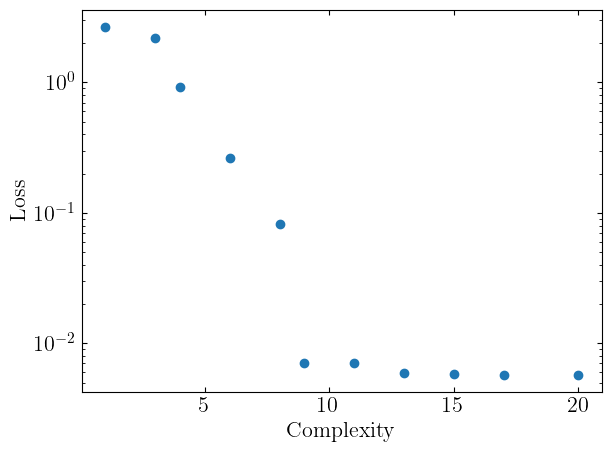

In [220]:
df = model.equations_


plt.scatter(df['complexity'], df['loss'])

plt.yscale('log')
plt.xlabel('Complexity')
plt.ylabel('Loss')

plt.tight_layout()

In [218]:
def f_decay(X, a,b,c,d):
    return X[:,0]* (a + c/ (b + (X[:,1])))

import scipy.optimize as opt

print(X.shape)
popt, pcov = opt.curve_fit(f_decay, X, y)

print(popt)



/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_54234/7763344.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = opt.curve_fit(f_decay, X, y)


(34000, 2)
[ -2.06902239   0.88250516 -26.4893203    1.        ]


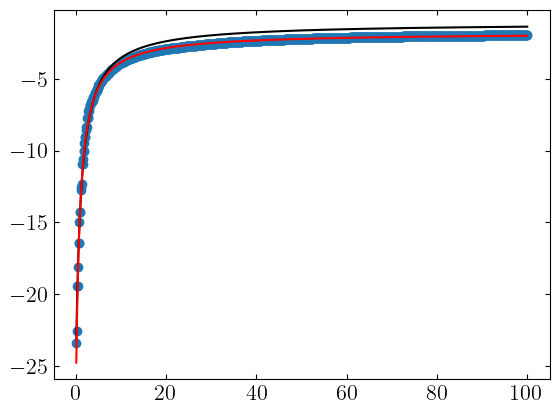

In [213]:

j = 1
X_fit = np.column_stack([
    dI_decay[j,:].flatten(),
    t_decay[j,:].flatten()
])
plt.scatter(X_fit[:,1],decays[j,:])


plt.plot(X_fit[:,1], f_decay(X_fit, *popt), color = 'k', label = 'Curve fit' )
plt.plot(X_fit[:,1], model.predict(X_fit), color = 'r', label = 'Symbolic regression' )

#plt.plot(X[ind,1], f_decay(X[ind,:], *popt), color = 'k', label = 'Curve fit' )

In [216]:
y_pred = model.predict(X)
y_pred = y_pred.reshape(decays.shape[0],decays.shape[1])    

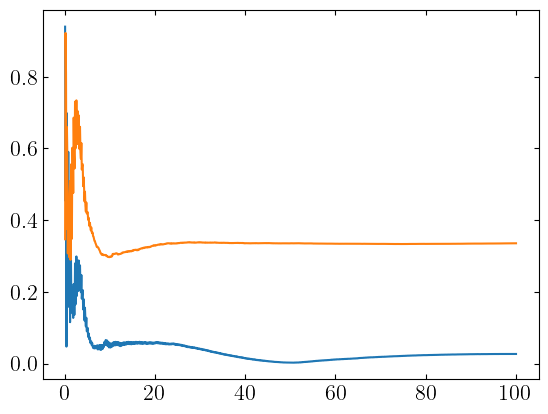

In [217]:
e_mean = np.mean(np.abs(y_pred - decays),axis = 0)
e_fit = np.abs(f_decay(X, *popt).reshape(decays.shape[0],decays.shape[1]) - decays)
plt.plot(t_decay[0,:],e_mean)
plt.plot(t_decay[0,:],e_fit.mean(axis = 0), label = 'Curve fit error')